**SECTION A - MULTIPLE CHOICE**

1. B
2. C
3. B
4. B
5. B
6. C
7. B
8. C
9. B
10. A
11. A
12. B
13. C
14. B
15. A
16. B
17. B
18. B
19. B
20. B

**SECTION B - STRUCTURED QUESTIONS**

QUESTION 1 - Python Basics

1. a variable is a name used to store a value whilst a value is the data we want to input into our code to use for further data functions.

2. student_name & age

3. 2student & class

4. Indentation matters in python not only because it is a core part of python syntax but also because it makes code easier to read and/or debug.

5. #lets input student details

QUESTION 2 - CODE INTERPRETATION

In [5]:
scores = [45,67,89,32,76]

total = 0

for score in scores:
  total = total + score

  average = total / len(scores)

  print(average)

9.0
22.4
40.2
46.6
61.8


In [4]:
print (type(scores))
print(len(scores))

<class 'list'>
5


6. scores is a list

7. allows us to process each item individually

8. len(scores) returns the number of values in the list.

9. 61.8

10. The code calculates the average by dividing each total by the total number of scores in the list i.e it recalculates average everytime it adds a new value to the existing total by dividing it by the total number of values in the list.

QUESTION 3 - DEBUGGING

In [10]:
student_name = "Tariro"
score = input("Enter score:")
score = float(score)

if score >= 50:
  print("pass")
else:
  print(fail)

Enter score:59.6
pass


QUESTION 4 -FUNCTIONS

In [29]:
scores = {
    "math" : 70,
    "reading" : 80,
    "writing" : 90
    }

def calculate_average(scores):
  return sum(scores)/len(scores)

  score = scores["math"] + scores["reading"] + scores["writing"]

  print(calculate_average(score))

**SECTION 5 - SHORT ESSAY/ EXPLANATION QUESTIONS**

QUESTION 1

Python is a programming language that allows us to give instructions to a computer. It is useful for Data science, AI and Machine Learning because it is beginner friendly and readable i.e it is an ideal starting point for thoseventuring into data analytics. Furthermore, it has a vast amount of libraries and frameworks that can be used for computing and visualisation which makes data manipulation and analysis easier and makes Python the ideal language to use. Libraries such as pandas make data cleaning and preprocessing tasks easier whilst matplotlib and seaborn enable for detailed data visualisation.

QUESTION 2
Exploratory Data Analysis, or EDA, is the process of investigating a dataset before making conclusions or building a model. This process includes data inspection whereby  we check the kind of data we are using, size, and how it is organised. This also includes checking for missing values and deciding how to best handle them to ensure that they do not affect the final results and interpretation.

**SECTION D - STUDENT PERFORMANCE DATA ANALYSIS PROJECT**

# **DATA SCIENCE AND ANALYTICS**

**NAME: NATASHA OLORATO OITSILE**

**DATE: 26 SEPTEMBER 2026**

**ASSESSMENT: INTRODUCTION TO PROGRAMMING IN PYTHON FOR DATA SCIENCE AND AI**

In [73]:
#Importing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

print("notebook setup complete")

notebook setup complete


In [97]:
def Student_Performance_data():

    possible_paths = [
        "/content/StudentsPerformance.csv"
    ]

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [112]:
print("Shape:", df.shape)
df.shape

print("columns:",df.columns)

print("Dataset information:")
df.info()

print("Data description:")
df.describe()

df.isnull().sum()

missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent.round(2)
})

missing_report[missing_report["missing_count"] > 0].head(20)

df.duplicated().sum()

Shape: (1000, 8)
columns: Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
Data description:


np.int64(0)

**FEATURE ENGINEERING**

In [118]:
df["total_score"] = df["math score"] + df["reading score"] + df["writing score"]
df["average_score"] = df["total_score"]/3
df["passed"] = np.where(df["average_score"] >= 50, "Pass", "Fail")
def classify_performance(avg):
    if avg >= 80:
        return "Excellent"
    elif avg >= 65:
        return "Good"
    elif avg >= 50:
        return "Pass"
    else:
        return "Needs Support"

# Apply the function to the average_score column
df["passed"] = df["average_score"].apply(classify_performance)

df[["average_score", "passed"]]


,average_score,passed
0,72.666667,Good
1,82.333333,Excellent
2,92.666667,Excellent
3,49.333333,Needs Support
4,76.333333,Good
...,...,...
995,94.000000,Excellent
996,57.333333,Pass
997,65.000000,Good
998,74.333333,Good


In [129]:
df.groupby("gender")["average_score"].mean()


,average_score
gender,
female,69.569498
male,65.837483


In [120]:
df.groupby("lunch")["average_score"].mean()

,average_score
lunch,
free/reduced,62.199061
standard,70.837209


In [121]:
df.groupby("test preparation course")["average_score"].mean()

,average_score
test preparation course,
completed,72.669460
none,65.038941


In [122]:
df.groupby("parental level of education")["average_score"].mean()

,average_score
parental level of education,
associate's degree,69.569069
bachelor's degree,71.923729
high school,63.096939
master's degree,73.598870
some college,68.476401
some high school,65.108007


In [123]:
df["passed"].value_counts()

,count
passed,
Good,403
Pass,296
Excellent,198
Needs Support,103


In [127]:
score_columns = ["math score","reading score","writing score"]

for column in score_columns:
  print(column,df[column].mean())

math score 66.089
reading score 69.169
writing score 68.054


**Data Visualization**



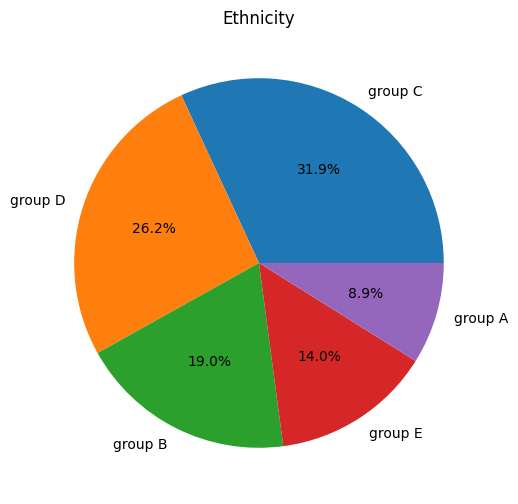

In [131]:
race_counts = df["race/ethnicity"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(race_counts.values, labels=race_counts.index, autopct="%1.1f%%")
plt.title("Ethnicity")
plt.show()

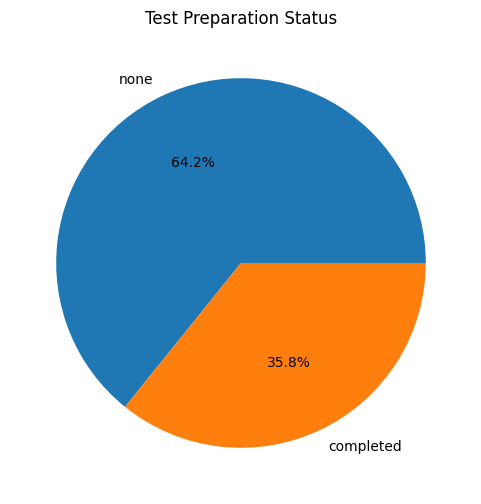

In [133]:
prep_counts = df["test preparation course"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(prep_counts.values, labels=prep_counts.index, autopct="%1.1f%%")
plt.title("Test Preparation Status")
plt.show()

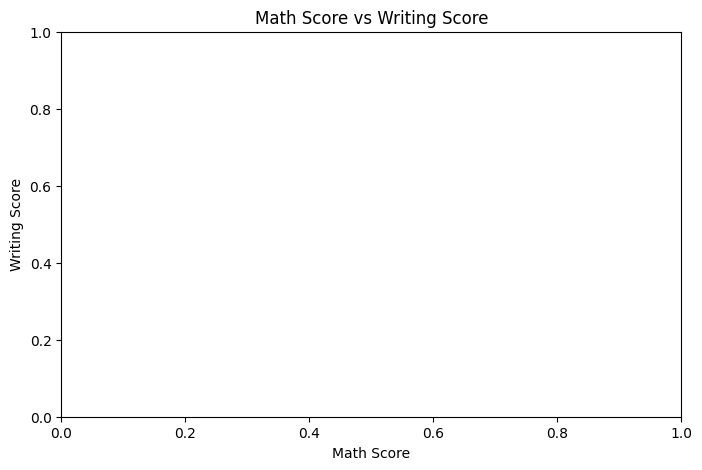

In [137]:
plt.figure(figsize=(8, 5))
#sns.scatterplot(data=df, x="math score", y="writing_score")
plt.title("Math Score vs Writing Score")
plt.xlabel("Math Score")
plt.ylabel("Writing Score")
plt.show()